# Havlicek Benchmark

Havlicek dataset has to yield:
- 0.5 accuracy in classical kernel $\rightarrow$ done
- 1.0 accuracy in quantum kernel

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from config.config import *
from config.experiments import ExperimentConfig
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.data.synthetic import *
from src.utils.visuals import *
from src.optimization.classical_base import classical_benchmark

RESULTS_DIR = 'Results/Havlicek Benchmark'

## 0. Classical Performance

In [ ]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_classical = []
errs_classical = []
for delta in deltas:
    accs = []
    for seed in range(10):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classical.append(np.mean(accs))
    errs_classical.append(np.std(accs))

data = {'deltas': deltas, 'accuracies_classical': accuracies_classical, 'errs_classical': errs_classical}
df = pd.DataFrame(data)
df.to_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv', index=False)

In [4]:
# open the csv file and plot the results
df = pd.read_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv')
deltas, accuracies_classical, errs_classical = df['deltas'], df['accuracies_classical'], df['errs_classical']

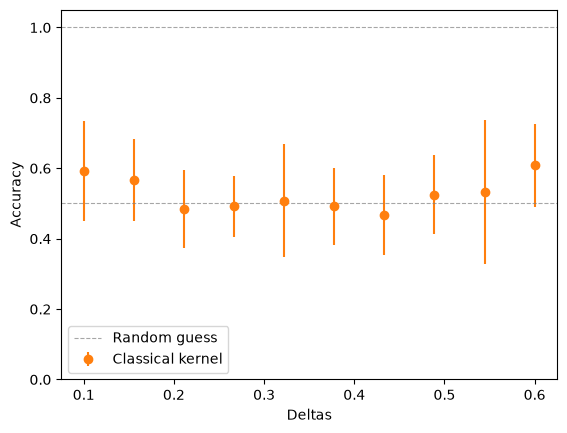

In [5]:
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 2. Quantum Optuna

- Add rescaling to preprocess

In [6]:
def preprocess_synthetic(X, y, tts_seed=TTS_SEED):
    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=tts_seed, stratify=y)

    # Scale features to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [ ]:
delta = 0.5
accuracies_qo = []

config = ExperimentConfig(
    name = f'{RESULTS_DIR}/optuna 100 d{delta}',
    optimizer = 'optuna',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_trials': 100},
)
for seed in range(9):
    config.name = f'{RESULTS_DIR}/optuna 100 d{delta} s{seed}'
    X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
    X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
    
    trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    accuracies_qo.append(results['accuracy'])
    
    unique, counts = np.unique(results['y_pred'], return_counts=True)
    print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")

Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s0'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s0'
delta= 0.5 seed=0: acc=0.417, predicted counts={-1: 5, 1: 7}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s1'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s1'
delta= 0.5 seed=1: acc=0.750, predicted counts={-1: 5, 1: 7}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s2'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s2'
delta= 0.5 seed=2: acc=0.417, predicted counts={-1: 7, 1: 5}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s3'
Loading cached SVM results for 'Results/Havlicek Benchmark/optuna 100 d0.5 s3'
delta= 0.5 seed=3: acc=0.667, predicted counts={-1: 8, 1: 4}
Loading cached candidate for 'Results/Havlicek Benchmark/optuna 100 d0.5 s4'
Loading cached SVM results for 'Results/Havlicek Benchm

In [1]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
for n in range(9):
    plt.scatter(delta, accuracies_qo[n])
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

NameError: name 'plt' is not defined

## 2. Kernel with phases

Now the candidate has `N_LAYERS` worth of rotation gates after a stage of entangling. The new candidate:
- Reuses `OptunaGene`class
- 

In [ ]:
import pennylane as qml
from src.circuit.candidates import Candidate
from src.circuit.genes import OptunaGene
n_qubits = N_QUBITS

class HavlicekCandidate(Candidate):
    def __init__(self, n_qubits: int, n_layers: int, gates:list, angles:list):
        super().__init__(n_qubits, n_layers)

        # Build the gene dictionary for this candidate by calling the OptunaGene class
        for gate, angle in zip(gates, angles):
            gene = OptunaGene(gate, angle)
            self.genes.append(gene)


def quantum_kernel_matrix_phases(X1, X2 = None):

    def build_circuit(candidate, x):
        gene_idx = 0

        # entangling phase
        for qubit in range(candidate.n_qubits):
            qml.Hadamard(wires=qubit)

        for layer in range(candidate.n_layers):
            for qubit in range(candidate.n_qubits):
                # Obtain info from candidate -> gene -> gate + angle
                gene = candidate.get_ith_gene(gene_idx)
                info = gene.get_gene_info()
                
                gate = info['gate']
                angle = info['angle']